# CFADs and time-height sections of MRR data for individual events

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** January 2025

Plot time-height cross-sections of MRR reflectivity and CFADs for three representative storm events (S/SWIVT, Frontal, NW Postfrontal) at two mountain sites.

- **Alta Atwater** (Alta, UT)
- **Highland High** (Highland, UT)

Three storm-type case studies are analysed:

| Label | Event | Period (UTC) |
|-------|-------|--------------|
| S/SWIVT | South/Southwest flow with high IVT | 2023-01-09 23:00 – 2023-01-10 11:00 |
| Frontal (FR) | Frontal | 2023-02-21 23:00 – 2023-02-22 11:00 |
| NW Postfrontal (NWPF) | Northwest Postfrontal | 2022-12-13 23:00 – 2022-12-14 11:00 |

In [1]:
# Imports
import os
import sys
import glob
import numpy as np
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import pandas as pd
import math
import pyart
from MRR_functions import (get_files, hist2d_height)  # CFAD helper functions



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
site = 'Alta'
print('Working on MRR plots for {}'.format(site))

if site == 'Alta':
    site_title = 'Alta Atwater'
    site_key = 'ATW'

if site == 'Highland':
    site_title = 'Highland High'
    site_key = 'HGH'


# ── Paths (update as needed) ──────────────────────────────────────────────────
HOME = '/path/to/home'
Fig_Dir = 'Fig/'


Working on MRR plots for Alta


In [3]:
# ── CFAD variable settings ───────────────────────────────────────────────────
variable = 'Ze'

def calc_percentile(ds):
    """
    Calculate the 25th, 50th, and 75th percentiles of reflectivity
    over all time steps at each height level.
    """
    q25_Ze = np.nanpercentile(ds['Ze'].values, 25, axis=0)
    q50_Ze = np.nanpercentile(ds['Ze'].values, 50, axis=0)
    q75_Ze = np.nanpercentile(ds['Ze'].values, 75, axis=0)
    return q25_Ze, q50_Ze, q75_Ze


variable_dict = {
                    # bin width, min value, max value, title
    'Ze':           [1.5, -20, 40,  'Reflectivity (dBZ$_{\\mathrm{e}}$)'],
}

# CFAD plot settings
variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = (
    variable_dict[variable][0],
    variable_dict[variable][1],
    variable_dict[variable][2],
    variable_dict[variable][3],
)

# settings for CFAD
range_gate_start = 3
min_frac_thres   = 0.2
cfad_vmax        = 30
bottom           = 1000   # lower y-axis limit (m MSL)

# For plotting
fig_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
fs = 16


# Prepare for Plotting

In [4]:
# Representative 12-hour time windows for each storm type
time_period_SIVT = [('2023-01-09 23:00:00', '2023-01-10 11:00:00', 'SIVT')]
time_period_FR   = [('2023-02-21 23:00:00', '2023-02-22 11:00:00', 'FR')]
time_period_NWPF = [('2022-12-13 23:00:00', '2022-12-14 11:00:00', 'NWPF')]

time_period_list = [time_period_SIVT, time_period_FR, time_period_NWPF]


In [5]:
def prepare_data(files, start_time, end_time):
    """
    Load and pre-process MRR NetCDF files into a cleaned xarray Dataset.

    Parameters
    ----------
    files : list of str
        Paths to NetCDF files to load.
    start_time, end_time : str
        ISO-format time strings for the desired time window.

    Returns
    -------
    data : xarray.Dataset
        Cleaned dataset with height_ASL as a dimension.
    MRR_elevation : float
        Instrument elevation (m MSL).
    """
    data = xr.open_mfdataset(files)
    data['time'] = pd.to_datetime(data.time.values, unit='s')
    data = data.drop_duplicates(dim='time', keep=False)
    data = data.sortby('time')
    data = data.sel(time=slice(start_time, end_time))

    # Mask physically implausible values
    for var in ['Ze', 'spectralWidth', 'W']:
        data[var].values = np.where(
            (data[var] < -1000) | (data[var] > 1000), np.nan, data[var]
        )

    # Convention: positive W is upward (away from MRR)
    data['W'] *= -1

    # Get height data
    height = data.height.values[0]

    # Get mrr elevation
    try:
        MRR_elevation = data.MRR_elevation.values[0]
    except Exception:
        MRR_elevation = data.MRR_elevation.values

    # Drom data not needed
    data = data.drop_vars(['lat', 'lon', 'height', 'MRR_elevation'])

    # Add height above sea level as a coordinate to the dataset
    height_ASL = height + MRR_elevation
    data = data.rename_dims({'range': 'height_ASL'}).assign_coords(height_ASL=height_ASL)
    data = data.assign_coords(height=('height_ASL', height))

    return data, MRR_elevation


In [6]:
def get_files(time_period_start, time_period_end):
    """
    Return lists of 30-m and 180-m range-gate NetCDF file paths for
    both Alta and Highland sites covering the requested time window.
    """
    # Get the dates of the data
    dates_to_plot = pd.date_range(time_period_start, time_period_end, freq='12h')

    # empty lists for the data
    files_180_Alta    = []
    files_30_Alta     = []
    files_180_Highland = []
    files_30_Highland  = []

    # Loop through and add the needed files to the list
    for site, files_180, files_30 in [
        ('Alta',     files_180_Alta,     files_30_Alta),
        ('Highland', files_180_Highland, files_30_Highland),
    ]:
        DATA_DIR = (
            HOME
            + f'/steenburgh-group12/peter/WasatchDeployment_2022_2024_fromLaptop/{site}/MRR/NetCDF/'
        )
        for date in dates_to_plot:
            month = str(date.month).zfill(2)
            day   = str(date.day).zfill(2)
            year  = date.year

            file_30  = DATA_DIR + f'{year}{month}/condensed_processed_{month}{day}_030m.nc'
            file_180 = DATA_DIR + f'{year}{month}/condensed_processed_{month}{day}_180m.nc'

            if file_180 not in files_180:
                files_180.append(file_180)
            if file_30 not in files_30:
                files_30.append(file_30)

    return files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland


In [7]:
# Load and subset MRR data for each storm event

# S/SWIVT
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_SIVT[0][0], time_period_SIVT[0][1]
)
# Get the data for SIVT events
ds_180_Alta,     MRR_elevation_Alta     = prepare_data(files_180_Alta,     time_period_SIVT[0][0], time_period_SIVT[0][1])
ds_30_Alta,      MRR_elevation_Alta     = prepare_data(files_30_Alta,      time_period_SIVT[0][0], time_period_SIVT[0][1])
ds_180_Highland, MRR_elevation_Highland = prepare_data(files_180_Highland, time_period_SIVT[0][0], time_period_SIVT[0][1])
ds_30_Highland,  MRR_elevation_Highland = prepare_data(files_30_Highland,  time_period_SIVT[0][0], time_period_SIVT[0][1])

# Select for just period of interest
alta180_SIVT    = ds_180_Alta.sel(time=slice(time_period_SIVT[0][0], time_period_SIVT[0][1]))
highland180_SIVT = ds_180_Highland.sel(time=slice(time_period_SIVT[0][0], time_period_SIVT[0][1]))
alta30_SIVT     = ds_30_Alta.sel(time=slice(time_period_SIVT[0][0], time_period_SIVT[0][1]))
highland30_SIVT  = ds_30_Highland.sel(time=slice(time_period_SIVT[0][0], time_period_SIVT[0][1]))


# Frontal
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_FR[0][0], time_period_FR[0][1]
)
# Get the data for Frontal events
ds_180_Alta,     MRR_elevation_Alta     = prepare_data(files_180_Alta,     time_period_FR[0][0], time_period_FR[0][1])
ds_30_Alta,      MRR_elevation_Alta     = prepare_data(files_30_Alta,      time_period_FR[0][0], time_period_FR[0][1])
ds_180_Highland, MRR_elevation_Highland = prepare_data(files_180_Highland, time_period_FR[0][0], time_period_FR[0][1])
ds_30_Highland,  MRR_elevation_Highland = prepare_data(files_30_Highland,  time_period_FR[0][0], time_period_FR[0][1])

# Select for just period of interest
alta180_FR    = ds_180_Alta.sel(time=slice(time_period_FR[0][0], time_period_FR[0][1]))
highland180_FR = ds_180_Highland.sel(time=slice(time_period_FR[0][0], time_period_FR[0][1]))
alta30_FR     = ds_30_Alta.sel(time=slice(time_period_FR[0][0], time_period_FR[0][1]))
highland30_FR  = ds_30_Highland.sel(time=slice(time_period_FR[0][0], time_period_FR[0][1]))


# NW Postfrontal
files_30_Alta, files_180_Alta, files_30_Highland, files_180_Highland = get_files(
    time_period_NWPF[0][0], time_period_NWPF[0][1]
)
# Get the data for NW Postfrontal events
ds_180_Alta,     MRR_elevation_Alta     = prepare_data(files_180_Alta,     time_period_NWPF[0][0], time_period_NWPF[0][1])
ds_30_Alta,      MRR_elevation_Alta     = prepare_data(files_30_Alta,      time_period_NWPF[0][0], time_period_NWPF[0][1])
ds_180_Highland, MRR_elevation_Highland = prepare_data(files_180_Highland, time_period_NWPF[0][0], time_period_NWPF[0][1])
ds_30_Highland,  MRR_elevation_Highland = prepare_data(files_30_Highland,  time_period_NWPF[0][0], time_period_NWPF[0][1])

# Select for just period of interest
alta180_PF    = ds_180_Alta.sel(time=slice(time_period_NWPF[0][0], time_period_NWPF[0][1]))
highland180_PF = ds_180_Highland.sel(time=slice(time_period_NWPF[0][0], time_period_NWPF[0][1]))
alta30_PF     = ds_30_Alta.sel(time=slice(time_period_NWPF[0][0], time_period_NWPF[0][1]))
highland30_PF  = ds_30_Highland.sel(time=slice(time_period_NWPF[0][0], time_period_NWPF[0][1]))


In [8]:
def gather_data(time_period):
    """
    Load and return pre-processed time-height arrays for both Alta and Highland
    at 30-m and 180-m range-gate resolution.

    Returns
    -------
    Tuple of (times, heights_ASL, Z, W) arrays for each site/range-gate combination.
    """
    start_time = pd.to_datetime(time_period[0][0])
    curr_time  = pd.to_datetime(time_period[0][1])
    event_type = time_period[0][2]

    # Get the dates to plot
    dates_to_plot = pd.date_range(start_time, curr_time, freq='12h')

    # #mpty lists to store the files
    files_180_Alta    = []
    files_30_Alta     = []
    files_180_Highland = []
    files_30_Highland  = []

    # Loop through the files and add to list of files to use
    for site, files_180, files_30 in [
        ('Alta',     files_180_Alta,     files_30_Alta),
        ('Highland', files_180_Highland, files_30_Highland),
    ]:
        DATA_DIR = (
            HOME
            + f'/steenburgh-group12/peter/WasatchDeployment_2022_2024_fromLaptop/{site}/MRR/NetCDF/'
        )
        for date in dates_to_plot:
            month = str(date.month).zfill(2)
            day   = str(date.day).zfill(2)
            year  = date.year

            file_30  = DATA_DIR + f'{year}{month}/condensed_processed_{month}{day}_030m.nc'
            file_180 = DATA_DIR + f'{year}{month}/condensed_processed_{month}{day}_180m.nc'

            if file_180 not in files_180:
                files_180.append(file_180)
            if file_30 not in files_30:
                files_30.append(file_30)

    ds_180_Alta,     _ = prepare_data(files_180_Alta,     start_time, curr_time)
    ds_30_Alta,      _ = prepare_data(files_30_Alta,      start_time, curr_time)
    ds_180_Highland, _ = prepare_data(files_180_Highland, start_time, curr_time)
    ds_30_Highland,  _ = prepare_data(files_30_Highland,  start_time, curr_time)

    # Extract arrays – 180-m range gate
    heights_ASL_Alta     = ds_180_Alta['height_ASL'].values
    times_Alta           = ds_180_Alta['time'].values
    Z_Alta               = ds_180_Alta['Ze'].T.values
    W_Alta               = ds_180_Alta['W'].T.values

    heights_ASL_Highland  = ds_180_Highland['height_ASL'].values
    times_Highland        = ds_180_Highland['time'].values
    Z_Highland            = ds_180_Highland['Ze'].T.values
    W_Highland            = ds_180_Highland['W'].T.values

    # Extract arrays – 30-m range gate
    heights_ASL_Alta_     = ds_30_Alta['height_ASL'].values
    times_Alta_           = ds_30_Alta['time'].values
    Z_Alta_               = ds_30_Alta['Ze'].T.values
    W_Alta_               = ds_30_Alta['W'].T.values

    heights_ASL_Highland_  = ds_30_Highland['height_ASL'].values
    times_Highland_        = ds_30_Highland['time'].values
    Z_Highland_            = ds_30_Highland['Ze'].T.values
    W_Highland_            = ds_30_Highland['W'].T.values

    return (
        times_Alta, heights_ASL_Alta, Z_Alta,
        times_Alta_, heights_ASL_Alta_, Z_Alta_,
        times_Highland, heights_ASL_Highland, Z_Highland,
        times_Highland_, heights_ASL_Highland_, Z_Highland_,
        W_Alta, W_Alta_, W_Highland, W_Highland_,
    )


In [9]:
# Extract all data for the plot
# By convention in code, _ at the end of a variable indicates 30-m data
times_Alta_SIVT, heights_ASL_Alta_SIVT, Z_Alta_SIVT, times_Alta_SIVT_, heights_ASL_Alta_SIVT_, Z_Alta_SIVT_, times_Highland_SIVT, heights_ASL_Highland_SIVT, Z_Highland_SIVT, times_Highland_SIVT_, heights_ASL_Highland_SIVT_, Z_Highland_SIVT_, W_Alta_SIVT, W_Alta_SIVT_, W_Highland_SIVT, W_Highland_SIVT_ = gather_data(time_period_SIVT)
times_Alta_FR, heights_ASL_Alta_FR, Z_Alta_FR, times_Alta_FR_, heights_ASL_Alta_FR_, Z_Alta_FR_, times_Highland_FR, heights_ASL_Highland_FR, Z_Highland_FR, times_Highland_FR_, heights_ASL_Highland_FR_, Z_Highland_FR_, W_Alta_FR, W_Alta_FR_, W_Highland_FR, W_Highland_FR_ = gather_data(time_period_FR)
times_Alta_NWPF, heights_ASL_Alta_NWPF, Z_Alta_NWPF, times_Alta_NWPF_, heights_ASL_Alta_NWPF_, Z_Alta_NWPF_, times_Highland_NWPF, heights_ASL_Highland_NWPF, Z_Highland_NWPF, times_Highland_NWPF_, heights_ASL_Highland_NWPF_, Z_Highland_NWPF_, W_Alta_NWPF, W_Alta_NWPF_, W_Highland_NWPF, W_Highland_NWPF_ = gather_data(time_period_NWPF)


In [10]:
# Some settings
hour_interval   = 6    # x-tick interval (hours)
minute_interval = 90   # finer x-tick interval (minutes)
start_ind       = 3    # skip lowest range gates

mergetop30index      = int(np.where(ds_30_Alta.height   == 810.)[0])
mergebottom180index  = int(np.where(ds_180_Alta.height  == 900.)[0])

labelpad = 0.03
fs = 13

# stuff for labels
ylabel  = 'Height (m MSL)'
ylabel_ = 'Height (m MSL)'

yticks = np.arange(1000,8001,1000)


/uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/uufs/chpc.utah.edu/comm

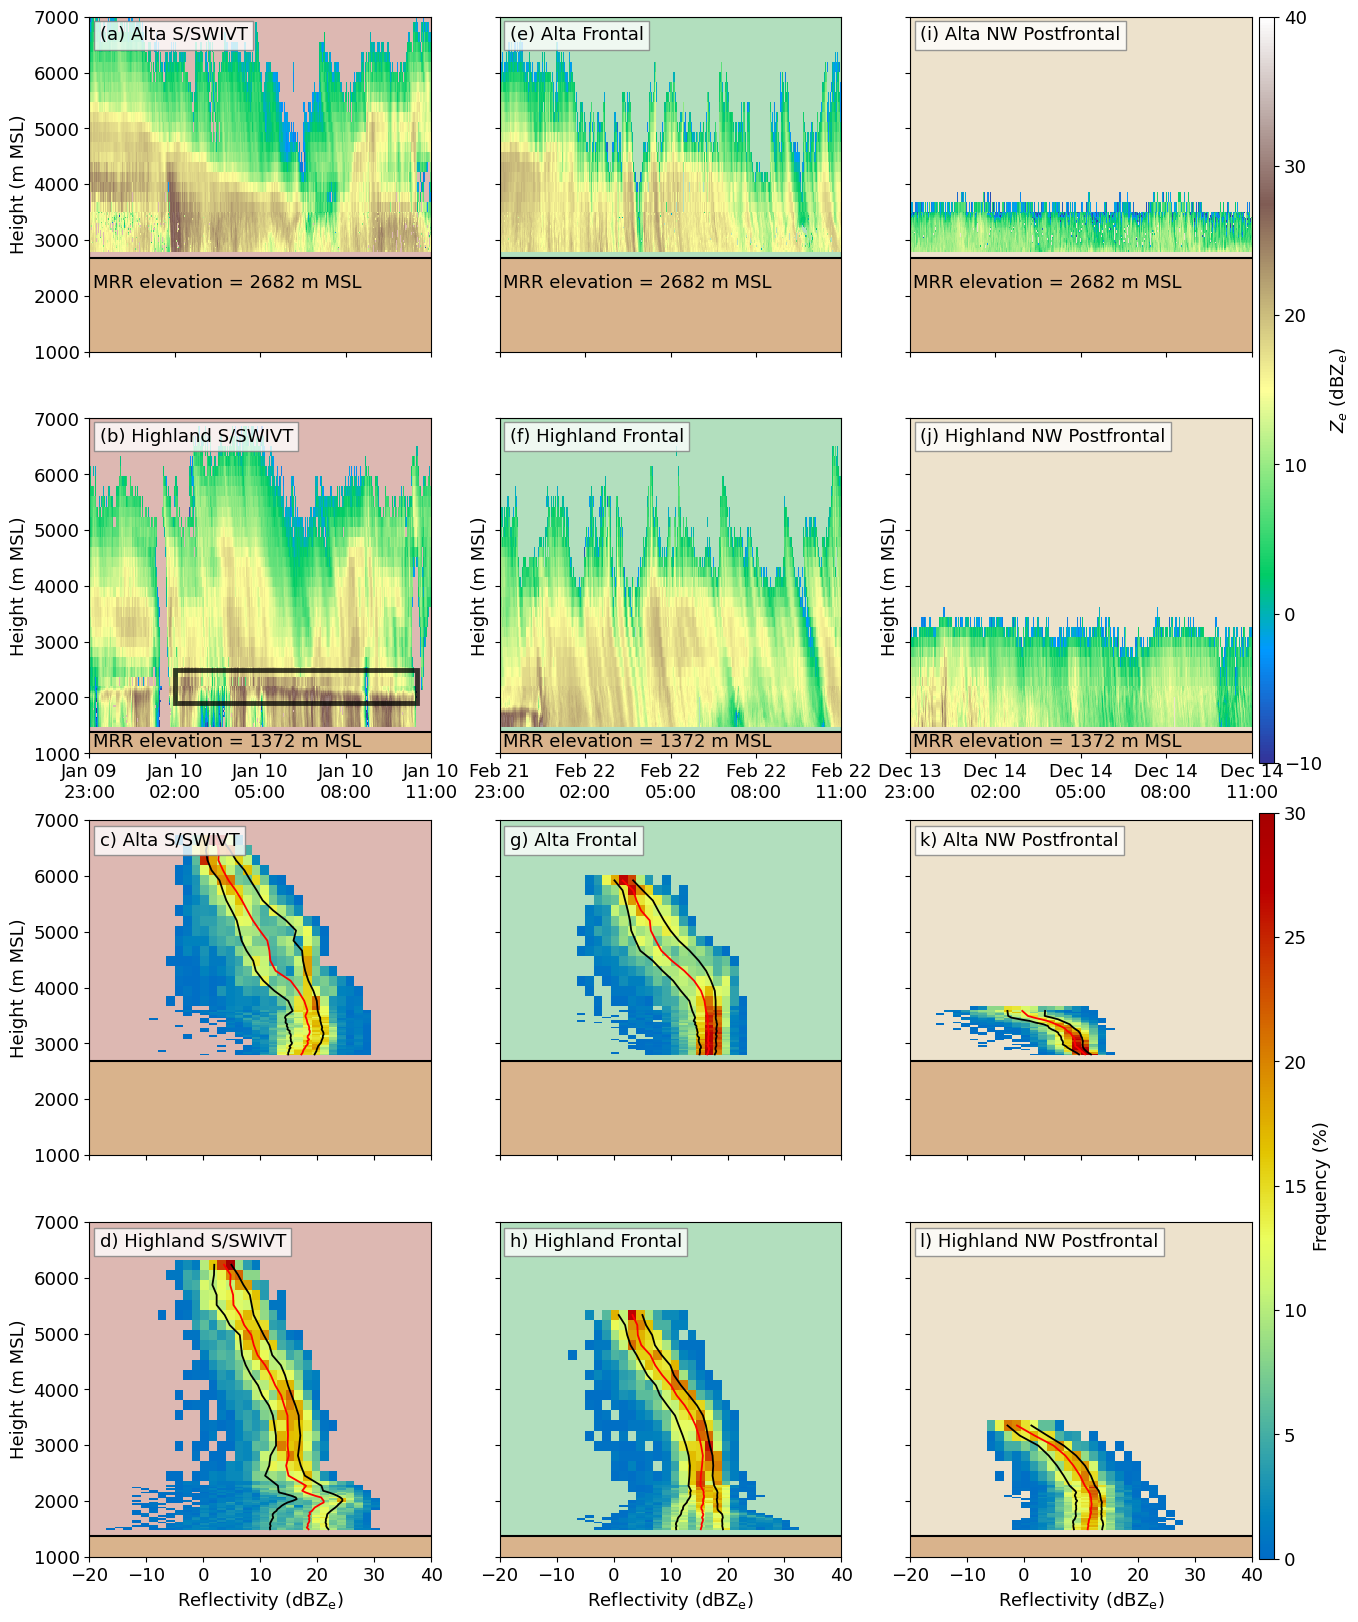

In [11]:
# Create figure and axes
# Here the _ indicates highland plots
fig, ((ax1, ax2, ax3), (ax1_, ax2_, ax3_), (ax4, ax5, ax6), (ax4_, ax5_, ax6_)) = plt.subplots(
    4, 3, facecolor='white', edgecolor='k', sharey=True, figsize=(15, 20)
)

# Share x-axes within each row pair so tick labels only appear on the bottom row
for ax_top, ax_bottom in zip([ax1, ax2, ax3], [ax1_, ax2_, ax3_]):
    ax_bottom.sharex(ax_top)
    ax_top.label_outer()

for ax_top, ax_bottom in zip([ax4, ax5, ax6], [ax4_, ax5_, ax6_]):
    ax_bottom.sharex(ax_top)
    ax_top.label_outer()


# ── Time-height cross-sections ───────────────────────────────────────────────
cmap = plt.cm.terrain
bot  = 800

plot_configs = [
    # (ax_alta, ax_highland, times_alta, hASL_alta, Z_alta, times_alta_, hASL_alta_, Z_alta_,
    #  times_hgh, hASL_hgh, Z_hgh, times_hgh_, hASL_hgh_, Z_hgh_, time_period, x_freq)
    (ax1,  ax1_,  times_Alta_SIVT,  heights_ASL_Alta_SIVT,  Z_Alta_SIVT,
            times_Alta_SIVT_,  heights_ASL_Alta_SIVT_,  Z_Alta_SIVT_,
            times_Highland_SIVT, heights_ASL_Highland_SIVT, Z_Highland_SIVT,
            times_Highland_SIVT_, heights_ASL_Highland_SIVT_, Z_Highland_SIVT_,
            time_period_SIVT, '3H'),
    (ax2,  ax2_,  times_Alta_FR,   heights_ASL_Alta_FR,   Z_Alta_FR,
            times_Alta_FR_,   heights_ASL_Alta_FR_,   Z_Alta_FR_,
            times_Highland_FR,  heights_ASL_Highland_FR,  Z_Highland_FR,
            times_Highland_FR_,  heights_ASL_Highland_FR_,  Z_Highland_FR_,
            time_period_FR, '3H'),
    (ax3,  ax3_,  times_Alta_NWPF, heights_ASL_Alta_NWPF, Z_Alta_NWPF,
            times_Alta_NWPF_, heights_ASL_Alta_NWPF_, Z_Alta_NWPF_,
            times_Highland_NWPF, heights_ASL_Highland_NWPF, Z_Highland_NWPF,
            times_Highland_NWPF_, heights_ASL_Highland_NWPF_, Z_Highland_NWPF_,
            time_period_NWPF, '3H'),
]

ref = None
# Loop through already defined plot configs
for (ax_a, ax_h,
     t_a, h_a, z_a, t_a_, h_a_, z_a_,
     t_h, h_h, z_h, t_h_, h_h_, z_h_,
     tp, freq) in plot_configs:

    # extract x ticks
    x_ticks      = pd.date_range(tp[0][0], tp[0][1], freq=freq)
    x_tick_labels = x_ticks.strftime('%b %d\n%H:%M')

    # Alta – 180-m and 30-m range gate merged
    ref = ax_a.pcolormesh(t_a,  h_a[start_ind:],                          z_a[start_ind:],                          cmap=cmap, vmin=-10, vmax=40)
    ref = ax_a.pcolormesh(t_a_, h_a_[start_ind:mergetop30index+1],        z_a_[start_ind:mergetop30index+1],        cmap=cmap, vmin=-10, vmax=40)
    ax_a.set_yticks(yticks, labels=yticks.astype(int), fontsize=fs)
    ax_a.set_ylim(bot,)
    ax_a.axhspan(bot, MRR_elevation_Alta, fc='#d9b38c')
    ax_a.axhline(MRR_elevation_Alta, color='black')
    ax_a.text(0.01, 0.19, f'MRR elevation = {MRR_elevation_Alta.astype(int)} m MSL',
              fontsize=fs, transform=ax_a.transAxes)

    # Highland – 180-m and 30-m range gate merged
    ref = ax_h.pcolormesh(t_h,  h_h[start_ind:],                          z_h[start_ind:],                          cmap=cmap, vmin=-10, vmax=40)
    ref = ax_h.pcolormesh(t_h_, h_h_[start_ind:mergetop30index+1],        z_h_[start_ind:mergetop30index+1],        cmap=cmap, vmin=-10, vmax=40)
    ax_h.set_xticks(x_ticks, labels=x_tick_labels, fontsize=fs)
    ax_h.set_yticks(yticks, labels=yticks.astype(int), fontsize=fs)
    ax_h.set_ylabel(ylabel, fontsize=fs)
    ax_h.set_ylim(bot,)
    ax_h.axhspan(bot, MRR_elevation_Highland, fc='#d9b38c')
    ax_h.axhline(MRR_elevation_Highland, color='black')
    ax_h.text(0.01, 0.02, f'MRR elevation = {MRR_elevation_Highland.astype(int)} m MSL',
              fontsize=fs, transform=ax_h.transAxes)


# Event-type background shading on time-height panels, colors for unique events
for ax in [ax1, ax1_]:
    ax.axvspan(pd.to_datetime(time_period_SIVT[0][0]), pd.to_datetime(time_period_SIVT[0][1]),
               color='xkcd:brick red', alpha=0.3, zorder=-1)
    ax.set_ylabel(ylabel, fontsize=fs)
for ax in [ax2, ax2_]:
    ax.axvspan(pd.to_datetime(time_period_FR[0][0]),   pd.to_datetime(time_period_FR[0][1]),
               color='xkcd:irish green', alpha=0.3, zorder=-1)
for ax in [ax3, ax3_]:
    ax.axvspan(pd.to_datetime(time_period_NWPF[0][0]), pd.to_datetime(time_period_NWPF[0][1]),
               color='xkcd:camel', alpha=0.3, zorder=-1)

# Bright-band annotation box (SIVT Highland panel)
start_box = datetime.datetime(2023, 1, 10, 2)
end_box   = datetime.datetime(2023, 1, 10, 10, 30)
bot_box, top_box = 1900, 2500
x_corners = np.array([mdates.date2num(start_box)] * 2 + [mdates.date2num(end_box)] * 2)
y_corners = np.array([bot_box, top_box, top_box, bot_box])
poly_corners = np.column_stack([x_corners, y_corners])
poly = mpatches.Polygon(poly_corners, closed=True, fc='black', ec='black',
                         fill=False, lw=3.5, zorder=4, alpha=0.75)
ax1_.add_patch(poly)

# Subplot labels – time-height panels
props = dict(boxstyle='square', facecolor='white', alpha=0.8, ec='gray')
for ax, label in [
    (ax1,  '(a) Alta S/SWIVT'),
    (ax1_, '(b) Highland S/SWIVT'),
    (ax2,  '(e) Alta Frontal'),
    (ax2_, '(f) Highland Frontal'),
    (ax3,  '(i) Alta NW Postfrontal'),
    (ax3_, '(j) Highland NW Postfrontal'),
]:
    ax.text(0.03, 0.93, label, transform=ax.transAxes, fontsize=fs, zorder=20, bbox=props)


# ── CFADs ────────────────────────────────────────────────────────────────────
# Get the axes for the plots and prepare data
axes        = [ax4,  ax5,  ax6,  ax4_,  ax5_,  ax6_]
data180_list = [alta180_SIVT, alta180_FR, alta180_PF,
                highland180_SIVT, highland180_FR, highland180_PF]
data30_list  = [alta30_SIVT,  alta30_FR,  alta30_PF,
                highland30_SIVT,  highland30_FR,  highland30_PF]
cfad_labels  = [
    'c) Alta S/SWIVT',      'g) Alta Frontal',      'k) Alta NW Postfrontal',
    'd) Highland S/SWIVT',  'h) Highland Frontal',  'l) Highland NW Postfrontal',
]

# Loop through axes, extract data, and plot the data
for i, ax in enumerate(axes):
    data180 = data180_list[i]
    data30  = data30_list[i]

    # Compute percentile profiles
    q25_Ze_180, q50_Ze_180, q75_Ze_180 = calc_percentile(data180)
    q25_Ze_30,  q50_Ze_30,  q75_Ze_30  = calc_percentile(data30)

    # Merge 30-m (low levels) and 180-m (upper levels) profiles
    q25 = np.concatenate([q25_Ze_30[:mergetop30index+1], q25_Ze_180[mergebottom180index:]])[range_gate_start:]
    q50 = np.concatenate([q50_Ze_30[:mergetop30index+1], q50_Ze_180[mergebottom180index:]])[range_gate_start:]
    q75 = np.concatenate([q75_Ze_30[:mergetop30index+1], q75_Ze_180[mergebottom180index:]])[range_gate_start:]
    height_ASL_merged = np.concatenate(
        [data30.height_ASL.values[:mergetop30index+1], data180.height_ASL.values[mergebottom180index:]]
    )

    # ── 180-m CFAD ──────────────────────────────────────────────────────────
    height_bins_width  = data180.height[1] - data180.height[0]
    height_bins_start  = data180.height_ASL[mergebottom180index] - height_bins_width / 2
    height_bins_stop   = data180.height_ASL[-1] + height_bins_width / 2

    # Get the 2d histogram
    results = hist2d_height(
        data180.isel(height_ASL=slice(range_gate_start, -1)),
        variable, variable_bins_width, variable_bins_start, variable_bins_stop,
        'height_ASL', height_bins_width, height_bins_start, height_bins_stop,
    )
    hist, height_edges, variable_edges = results

    # Sum over all height bins to determine CFAD
    hist_sum     = np.sum(hist, axis=1, keepdims=True)
    point_thres  = min_frac_thres * np.max(hist_sum)
    mask_valid   = hist_sum[:, 0] >= point_thres
    hist_masked  = np.where(mask_valid[:, None], hist, np.nan)

    with np.errstate(divide='ignore', invalid='ignore'):
        freq = (hist_masked / hist_sum) * 100
        freq[~mask_valid, :] = np.nan

    nan_freq_180     = np.where(freq == 0, np.nan, freq)  # Convert zeros to nan
    
    # Determine lowest level at which all CFAD values are nan (to stop the percentile lines at lower levels)
    first_all_nan    = np.min(np.where(np.all(np.isnan(nan_freq_180), axis=1))[0])

    # Plot data
    x_mesh, y_mesh = np.meshgrid(variable_edges, height_edges)
    p = ax.pcolormesh(x_mesh, y_mesh, nan_freq_180, cmap='pyart_HomeyerRainbow',
                      vmin=0, vmax=cfad_vmax, edgecolors='none', linewidth=0.4, antialiased=True)

    # ── 30-m CFAD ───────────────────────────────────────────────────────────
    height_bins_width = data30.height[1] - data30.height[0]
    height_bins_start = data30.height_ASL[0] - height_bins_width / 2
    height_bins_stop  = data30.height_ASL[-1] + height_bins_width / 2

    # Get the 2d histogram
    results = hist2d_height(
        data30.isel(height_ASL=slice(range_gate_start, -1)),
        variable, variable_bins_width, variable_bins_start, variable_bins_stop,
        'height_ASL', height_bins_width, height_bins_start, height_bins_stop,
    )
    hist, height_edges, variable_edges = results

    # Sum over all height bins to determine CFAD
    hist_sum    = np.sum(hist, axis=1, keepdims=True)
    point_thres = min_frac_thres * np.max(hist_sum)
    mask_valid  = hist_sum[:, 0] >= point_thres
    hist_masked = np.where(mask_valid[:, None], hist, np.nan)

    with np.errstate(divide='ignore', invalid='ignore'):
        freq = (hist_masked / hist_sum) * 100
        freq[~mask_valid, :] = np.nan

    nan_freq_30 = np.where(freq == 0, np.nan, freq)  # Convert zeros to nan

     # Plot data
    x_mesh, y_mesh = np.meshgrid(variable_edges, height_edges)
    p = ax.pcolormesh(x_mesh, y_mesh, nan_freq_30, cmap='pyart_HomeyerRainbow',
                      vmin=0, vmax=cfad_vmax, edgecolors='none', linewidth=0.4, antialiased=True)

    # Ground / below-instrument shading
    elev = MRR_elevation_Alta if i in [0, 1, 2] else MRR_elevation_Highland
    ax.axhspan(bottom, elev, fc='#d9b38c')
    ax.axhline(elev, color='black')

    # Add labels
    if i in [3, 4, 5]:
        ax.set_xlabel(xlabel, fontsize=fs)
    if i in [0, 3]:
        ax.set_ylabel('Height (m MSL)', fontsize=fs)

    # Add limits
    ax.set_xlim(variable_bins_start, variable_bins_stop)
    ax.set_ylim(bottom, 7000)
    ax.tick_params(axis='x', labelsize=fs)
    ax.tick_params(axis='y', labelsize=fs)

    # Percentile profiles based on where the lowest value is all nan (-3 cause that is the range gate start)
    n_plot = mergetop30index + first_all_nan + 1 - 3
    ax.plot(q25[:n_plot], height_ASL_merged[range_gate_start:range_gate_start + n_plot],
            color='black', lw=1.3, zorder=50)
    ax.plot(q75[:n_plot], height_ASL_merged[range_gate_start:range_gate_start + n_plot],
            color='black', lw=1.3, zorder=50)
    ax.plot(q50[:n_plot], height_ASL_merged[range_gate_start:range_gate_start + n_plot],
            color='red',   lw=1.3, zorder=50)

    # Add labels
    ax.text(0.03, 0.925, cfad_labels[i], transform=ax.transAxes,
            fontsize=fs, bbox=props, zorder=500)


# Event-type background shading on CFAD panels
for ax, color in [
    (ax4,  'xkcd:brick red'),
    (ax5,  'xkcd:irish green'),
    (ax6,  'xkcd:camel'),
    (ax4_, 'xkcd:brick red'),
    (ax5_, 'xkcd:irish green'),
    (ax6_, 'xkcd:camel'),
]:
    ax.set_facecolor(to_rgba(color, alpha=0.3))


# ── Colorbars ────────────────────────────────────────────────────────────────
cax_cfad = plt.axes([0.905, 0.109, 0.01, 0.373])
cb = plt.colorbar(p, cax=cax_cfad)
cb.ax.tick_params(labelsize=fs)
cb.set_label('Frequency (%)', fontsize=fs)

cax_ref = plt.axes([0.905, 0.507, 0.01, 0.373])
cb = plt.colorbar(ref, cax=cax_ref)
cb.ax.tick_params(labelsize=fs)
cb.set_label('$Z_e$ (dBZ$_{\\mathrm{e}}$)', fontsize=fs)

plt.subplots_adjust(hspace=0.2)

# Save and show
plt.savefig(Fig_Dir + '3_events_MRR_plot.png', dpi=300, bbox_inches='tight')
plt.show()
